In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('US_Accidents_March23.csv')
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [36]:
df.dtypes

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

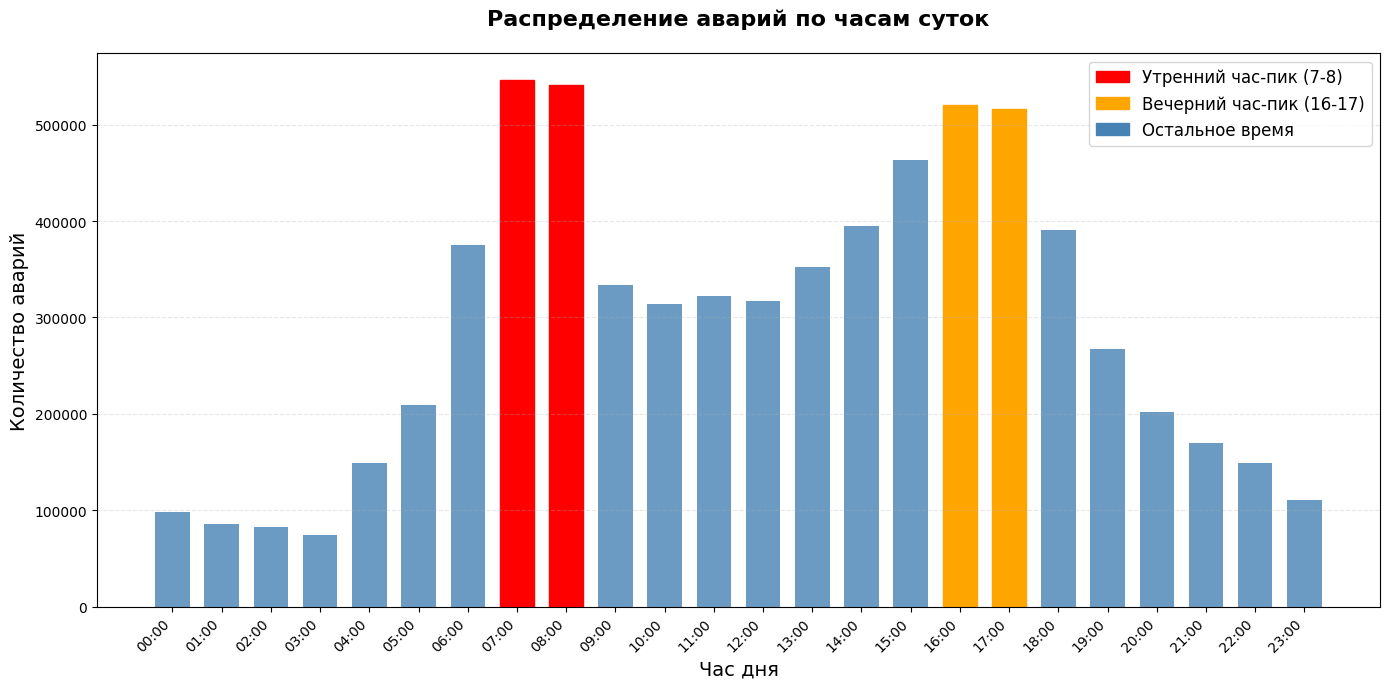

In [3]:
df_analysis = df.copy()

df_analysis['Start_Time'] = pd.to_datetime(df_analysis['Start_Time'], errors='coerce')

df_analysis = df_analysis.dropna(subset=['Start_Time'])

df_analysis['Hour'] = df_analysis['Start_Time'].dt.hour

hourly_counts = df_analysis.groupby('Hour').size()

all_hours = list(range(24))
hourly_counts_full = pd.Series(index=all_hours, data=0)
hourly_counts_full.update(hourly_counts)

morning_rush = [7, 8]
evening_rush = [16, 17]

plt.figure(figsize=(14, 7))

bars = plt.bar(all_hours, hourly_counts_full.values,
               color='steelBlue', alpha=0.8, width=0.7)

for hour in morning_rush:
    bars[hour].set_color('red')
    bars[hour].set_alpha(1.0)

for hour in evening_rush:
    bars[hour].set_color('orange')
    bars[hour].set_alpha(1.0)

plt.title('Распределение аварий по часам суток', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Час дня', fontsize=14)
plt.ylabel('Количество аварий', fontsize=14)

plt.xticks(range(0, 24, 1), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Утренний час-пик (7-8)')
orange_patch = mpatches.Patch(color='orange', label='Вечерний час-пик (16-17)')
blue_patch = mpatches.Patch(color='steelBlue', label='Остальное время')
plt.legend(handles=[red_patch, orange_patch, blue_patch], fontsize=12)

plt.tight_layout()
plt.show()

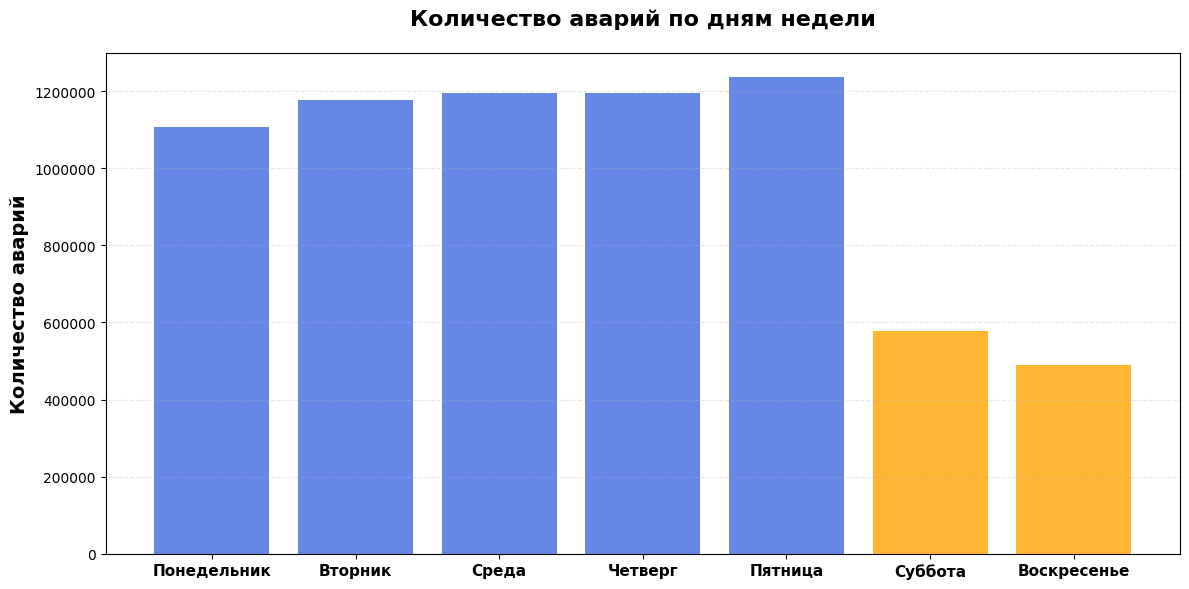

In [31]:
df_analysis = df.copy()

df_analysis['Start_Time'] = pd.to_datetime(df_analysis['Start_Time'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['Start_Time'])

df_analysis['DayOfWeek'] = df_analysis['Start_Time'].dt.dayofweek
df_analysis['DayName'] = df_analysis['Start_Time'].dt.day_name()

day_counts = df_analysis.groupby(['DayOfWeek', 'DayName']).size().reset_index(name='Count')
day_counts = day_counts.sort_values('DayOfWeek')

russian_days = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}

day_counts['DayName_RU'] = day_counts['DayName'].map(russian_days)

colors = ['royalBlue', 'royalBlue', 'royalBlue', 'royalBlue', 'royalBlue', 'orange', 'orange']

plt.figure(figsize=(12, 6))

bars = plt.bar(range(len(day_counts)), day_counts['Count'].values,
               color=colors, linewidth=1.5, alpha=0.8)

plt.xticks(range(len(day_counts)), day_counts['DayName_RU'].values,
           rotation=0, fontsize=11, fontweight='bold')
plt.title('Количество аварий по дням недели',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Количество аварий', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

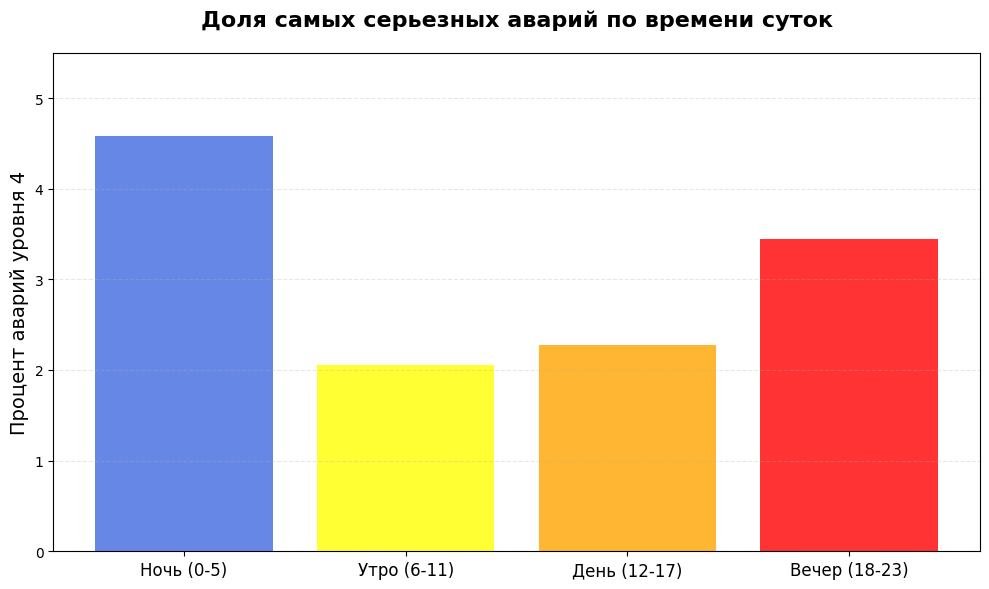

In [42]:
df_analysis = df.copy()

df_analysis['Start_Time'] = pd.to_datetime(df_analysis['Start_Time'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['Start_Time'])

df_analysis['Hour'] = df_analysis['Start_Time'].dt.hour

def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Утро (6-11)'
    elif 12 <= hour < 18:
        return 'День (12-17)'
    elif 18 <= hour < 24:
        return 'Вечер (18-23)'
    else:
        return 'Ночь (0-5)'

df_analysis['Time_of_Day'] = df_analysis['Hour'].apply(get_time_of_day)

df_analysis['Severity'] = pd.to_numeric(df_analysis['Severity'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['Severity'])

time_of_day_stats = df_analysis.groupby('Time_of_Day').agg({
    'Severity': ['mean', 'median', 'count', 'std']
}).round(2)

time_of_day_stats.columns = ['Avg_Severity', 'Median_Severity', 'Count', 'Std_Dev']
time_of_day_stats = time_of_day_stats.reindex(['Ночь (0-5)', 'Утро (6-11)', 'День (12-17)', 'Вечер (18-23)'])

colors = ['royalBlue', 'yellow', 'orange', 'red']

plt.figure(figsize=(10, 6))

level4_accidents_ratio = []
for time_of_day in time_of_day_stats.index:
    time_data = df_analysis[df_analysis['Time_of_Day'] == time_of_day]
    level4_count = len(time_data[time_data['Severity'] == 4])
    total_count = len(time_data)
    ratio = (level4_count / total_count) * 100 if total_count > 0 else 0
    level4_accidents_ratio.append(ratio)

bars_level4 = plt.bar(range(len(time_of_day_stats)), level4_accidents_ratio,
                      color=colors, linewidth=2, alpha=0.8)

plt.xticks(range(len(time_of_day_stats)), time_of_day_stats.index, rotation=0, fontsize=12)
plt.title('Доля самых серьезных аварий по времени суток', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Процент аварий уровня 4', fontsize=14)
plt.ylim(0, max(level4_accidents_ratio) * 1.2)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

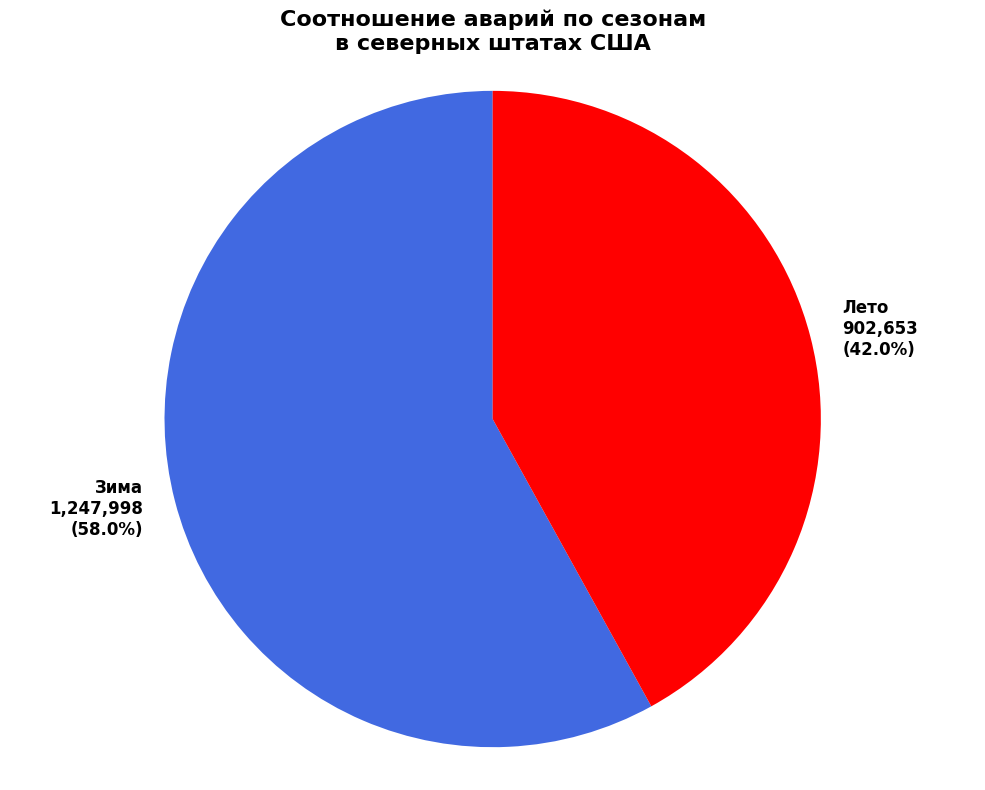

In [2]:
df_analysis = df.copy()

df_analysis['Start_Time'] = pd.to_datetime(df_analysis['Start_Time'], errors='coerce', format='mixed')

df_analysis = df_analysis.dropna(subset=['Start_Time'])

northern_threshold = 40.0
valid_coords = df_analysis.dropna(subset=['Start_Lat'])
northern_states = valid_coords[valid_coords['Start_Lat'] > northern_threshold]['State'].dropna().unique()

northern_df = df_analysis[df_analysis['State'].isin(northern_states)].copy()

northern_df['Month'] = northern_df['Start_Time'].dt.month

winter_months = [12, 1, 2]
summer_months = [6, 7, 8]

winter_accidents = northern_df[northern_df['Month'].isin(winter_months)]
summer_accidents = northern_df[northern_df['Month'].isin(summer_months)]

winter_count = len(winter_accidents)
summer_count = len(summer_accidents)

if winter_count > 0 and summer_count > 0:
    plt.figure(figsize=(10, 8))

    sizes = [winter_count, summer_count]
    labels = [f'Зима\n{winter_count:,}\n({winter_count/(winter_count+summer_count)*100:.1f}%)',
              f'Лето\n{summer_count:,}\n({summer_count/(winter_count+summer_count)*100:.1f}%)']
    colors = ['royalBlue', 'red']

    plt.pie(sizes, labels=labels, colors=colors,
            autopct='', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})

    plt.title('Соотношение аварий по сезонам\nв северных штатах США',
              fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

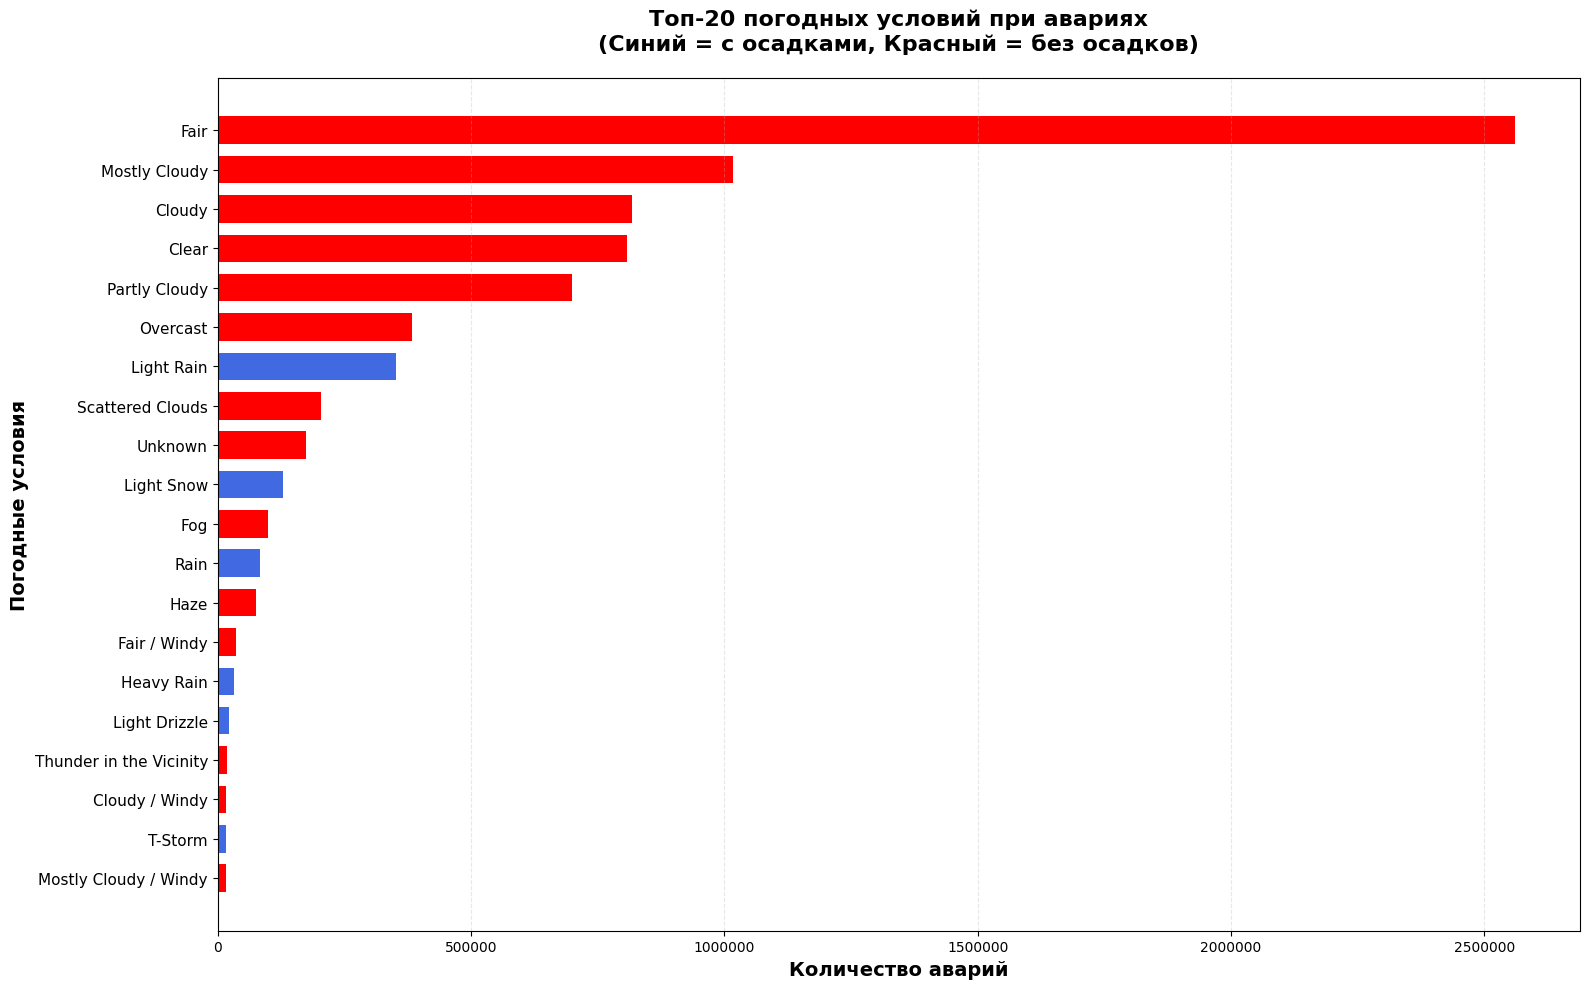

In [40]:
df_analysis = df.copy()

df_analysis['Weather_Condition'] = df_analysis['Weather_Condition'].fillna('Unknown')

precipitation_keywords = [
    'Rain', 'Snow', 'Drizzle', 'Sleet', 'Hail', 'Ice', 'Freezing',
    'Shower', 'Thunderstorm', 'T-Storm', 'Precipitation', 'Wintry'
]

def contains_precipitation(weather_str):
    if pd.isna(weather_str) or weather_str == 'Unknown':
        return False
    weather_str = str(weather_str).lower()
    for keyword in precipitation_keywords:
        if keyword.lower() in weather_str:
            return True
    return False

weather_counts = df_analysis['Weather_Condition'].value_counts().head(20)

weather_df = pd.DataFrame({
    'Weather_Condition': weather_counts.index,
    'Count': weather_counts.values,
    'Percentage': (weather_counts.values / len(df_analysis)) * 100
})

weather_df['Has_Precipitation'] = weather_df['Weather_Condition'].apply(
    lambda x: 'Да' if contains_precipitation(x) else 'Нет'
)

plt.figure(figsize=(16, 10))

top_20_weather = weather_counts.head(20)

colors = ['royalBlue' if contains_precipitation(w) else 'red' for w in top_20_weather.index]

bars = plt.barh(range(len(top_20_weather)), top_20_weather.values,
                color=colors, linewidth=1, height=0.7)

plt.yticks(range(len(top_20_weather)), top_20_weather.index, fontsize=11)
plt.xlabel('Количество аварий', fontsize=14, fontweight='bold')
plt.ylabel('Погодные условия', fontsize=14, fontweight='bold')
plt.title('Топ-20 погодных условий при авариях\n(Синий = с осадками, Красный = без осадков)',
          fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

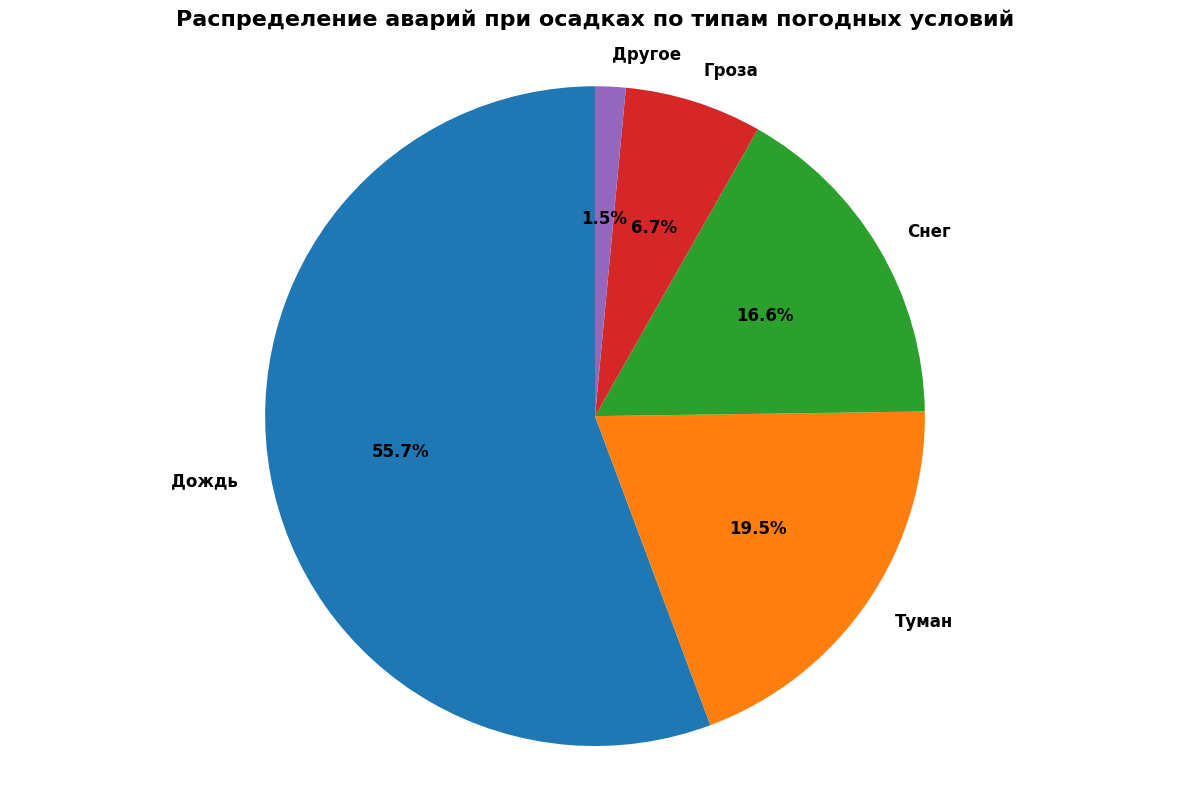

In [38]:
df_analysis = df.copy()

df_analysis['Weather_Condition'] = df_analysis['Weather_Condition'].fillna('Unknown')

precipitation_keywords = [
    'Rain', 'Snow', 'Drizzle', 'Sleet', 'Hail', 'Ice', 'Freezing',
    'Shower', 'Thunderstorm', 'T-Storm', 'Precipitation', 'Wintry'
]

def contains_precipitation(weather_str):
    if pd.isna(weather_str) or weather_str == 'Unknown':
        return False
    weather_str = str(weather_str).lower()
    for keyword in precipitation_keywords:
        if keyword.lower() in weather_str:
            return True
    return False

precipitation_categories = {
    'Дождь': ['Rain', 'Drizzle', 'Shower'],
    'Снег': ['Snow', 'Blizzard', 'Blowing Snow'],
    'Гроза': ['Thunder', 'T-Storm', 'Lightning'],
    'Туман': ['Fog', 'Mist', 'Haze'],
    'Другое': ['Dust', 'Sand', 'Smoke', 'Ice', 'Freezing', 'Sleet', 'Hail']
}

def categorize_precipitation(weather_str):
    weather_lower = str(weather_str).lower()
    for category, keywords in precipitation_categories.items():
        for keyword in keywords:
            if keyword.lower() in weather_lower:
                return category
    return 'Без осадков'

df_analysis['Precipitation_Category'] = df_analysis['Weather_Condition'].apply(categorize_precipitation)

category_counts = df_analysis['Precipitation_Category'].value_counts()

precip_categories_only = category_counts[category_counts.index != 'Без осадков']

plt.figure(figsize=(12, 8))

wedges, texts, autotexts = plt.pie(precip_categories_only.values,
                                    labels=precip_categories_only.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})


plt.title('Распределение аварий при осадках по типам погодных условий',
          fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')

legend_labels = []
for category, count in zip(precip_categories_only.index, precip_categories_only.values):
    percentage = (count / precip_categories_only.sum()) * 100
    legend_labels.append(f'{category}: {percentage:.1f}%')

plt.tight_layout()
plt.show()

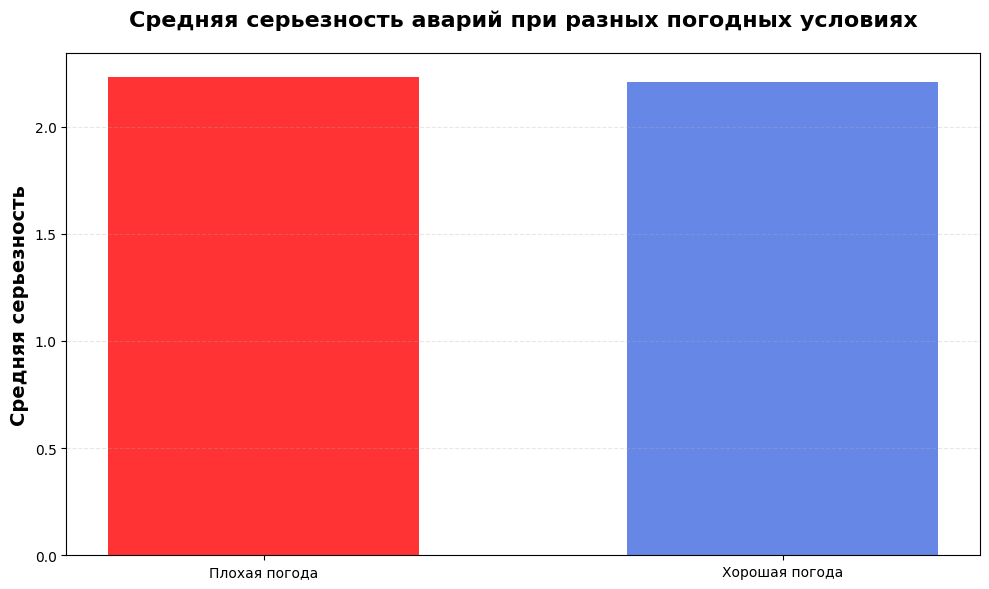

In [35]:
df_analysis = df.copy()

df_analysis['Weather_Condition'] = df_analysis['Weather_Condition'].fillna('Unknown')
df_analysis['Severity'] = pd.to_numeric(df_analysis['Severity'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['Severity'])

bad_weather_keywords = [
    'Rain', 'Drizzle', 'Shower', 'Precipitation', 'Wintry',
    'Snow', 'Sleet', 'Ice', 'Freezing', 'Hail', 'Blizzard',
    'Thunder', 'T-Storm', 'Lightning',
    'Fog', 'Mist', 'Haze', 'Smoke', 'Dust',
    'Squall', 'Tornado', 'Sandstorm', 'Duststorm'
]

def is_bad_weather(weather_str):
    if pd.isna(weather_str) or weather_str == 'Unknown':
        return False
    weather_lower = str(weather_str).lower()
    for keyword in bad_weather_keywords:
        if keyword.lower() in weather_lower:
            return True
    return False

df_analysis['Is_Bad_Weather'] = df_analysis['Weather_Condition'].apply(is_bad_weather)

bad_weather_accidents = df_analysis[df_analysis['Is_Bad_Weather'] == True]
good_weather_accidents = df_analysis[df_analysis['Is_Bad_Weather'] == False]

bad_weather_count = len(bad_weather_accidents)
good_weather_count = len(good_weather_accidents)
bad_weather_avg = bad_weather_accidents['Severity'].mean()
good_weather_avg = good_weather_accidents['Severity'].mean()

plt.figure(figsize=(10, 6))

categories = ['Плохая погода', 'Хорошая погода']
avg_values = [bad_weather_avg, good_weather_avg]
colors = ['red', 'royalBlue']

bars = plt.bar(categories, avg_values,
               color=colors, linewidth=2, alpha=0.8, width=0.6)

plt.title('Средняя серьезность аварий при разных погодных условиях',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Средняя серьезность', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

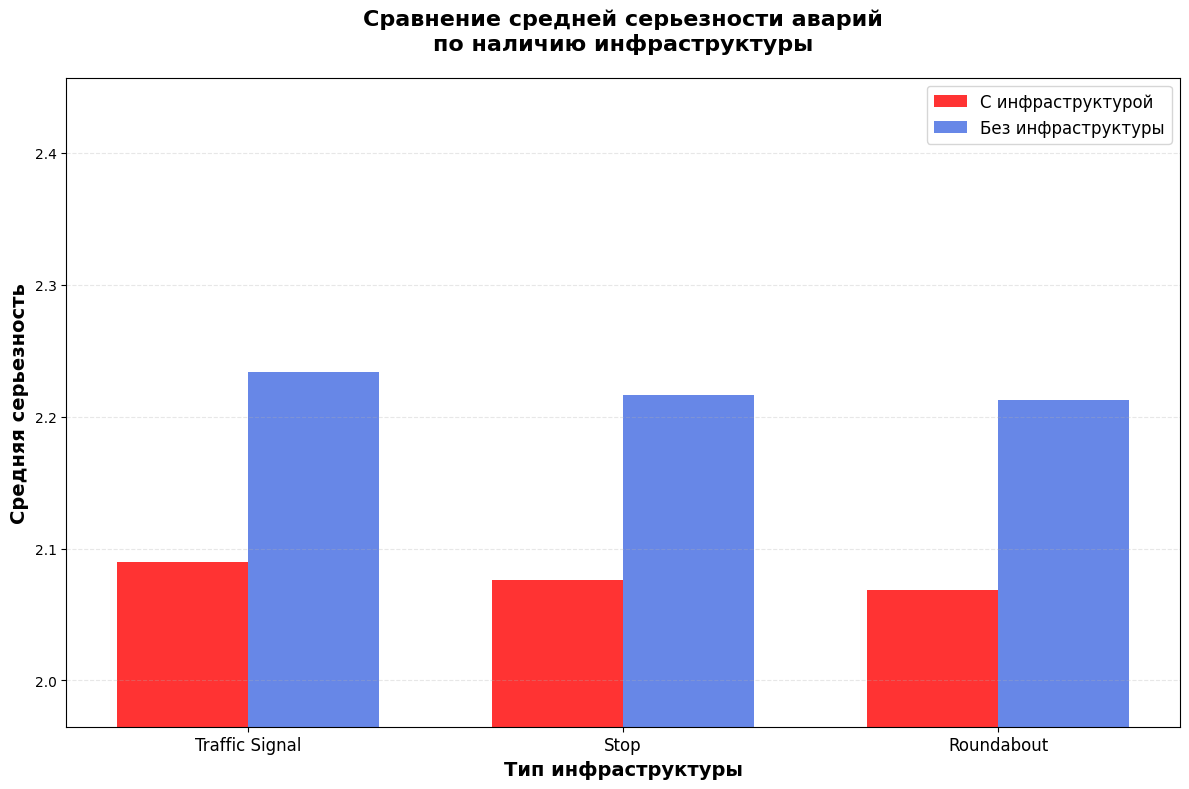

In [20]:
df_analysis = df.copy()

infrastructure_cols = ['Traffic_Signal', 'Stop', 'Roundabout']
available_cols = [col for col in infrastructure_cols if col in df_analysis.columns]

df_analysis['Severity'] = pd.to_numeric(df_analysis['Severity'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['Severity'])

for col in available_cols:
    df_analysis[col] = df_analysis[col].fillna(False)

    if df_analysis[col].dtype != bool:
        df_analysis[col] = df_analysis[col].astype(bool)

infrastructure_stats = {}

for col in available_cols:
    with_infra = df_analysis[df_analysis[col] == True]
    without_infra = df_analysis[df_analysis[col] == False]

    with_avg = with_infra['Severity'].mean()
    without_avg = without_infra['Severity'].mean()
    with_count = len(with_infra)
    without_count = len(without_infra)

    infrastructure_stats[col] = {
        'with_avg': with_avg,
        'without_avg': without_avg,
        'with_count': with_count,
        'without_count': without_count,
        'diff': with_avg - without_avg
    }

plt.figure(figsize=(12, 8))

categories = []
with_values = []
without_values = []
diffs = []

for col in available_cols:
    categories.append(col.replace('_', ' ').title())
    with_values.append(infrastructure_stats[col]['with_avg'])
    without_values.append(infrastructure_stats[col]['without_avg'])
    diffs.append(infrastructure_stats[col]['diff'])

x = list(range(len(categories)))
width = 0.35

bars_with = plt.bar([pos - width/2 for pos in x], with_values, width,
                   label='С инфраструктурой',
                   color='red',
                   edgecolor='black',
                   linewidth=1.5,
                   alpha=0.8)

bars_without = plt.bar([pos + width/2 for pos in x], without_values, width,
                      label='Без инфраструктуры',
                      color='royalBlue',
                      linewidth=1.5,
                      alpha=0.8)

plt.title('Сравнение средней серьезности аварий\nпо наличию инфраструктуры',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Средняя серьезность', fontsize=14, fontweight='bold')
plt.xlabel('Тип инфраструктуры', fontsize=14, fontweight='bold')
plt.xticks(x, categories, fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right')

all_values = with_values + without_values
y_min = min(all_values) * 0.95
y_max = max(all_values) * 1.1
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

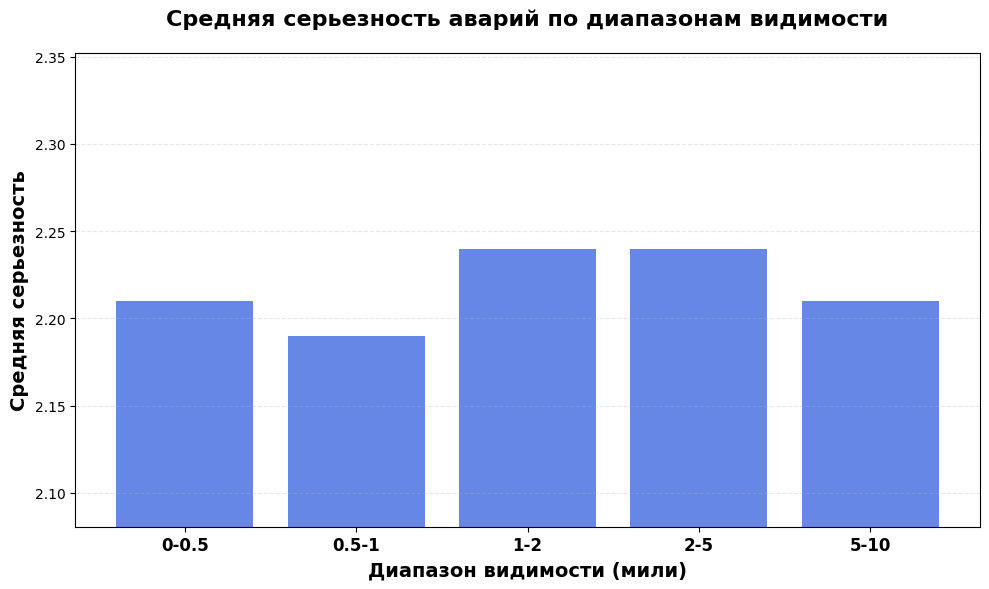

In [41]:
df_analysis = df.copy()

df_analysis['Visibility(mi)'] = pd.to_numeric(df_analysis['Visibility(mi)'], errors='coerce')
df_analysis['Severity'] = pd.to_numeric(df_analysis['Severity'], errors='coerce')

df_analysis = df_analysis.dropna(subset=['Visibility(mi)', 'Severity'])

visibility_threshold = df_analysis['Visibility(mi)'].quantile(0.99)
df_filtered = df_analysis[df_analysis['Visibility(mi)'] <= visibility_threshold].copy()

bins = [0, 0.5, 1, 2, 5, 10]
bin_labels = ['0-0.5', '0.5-1', '1-2', '2-5', '5-10']

df_filtered['Visibility_Bin'] = pd.cut(df_filtered['Visibility(mi)'], bins=bins, labels=bin_labels)

visibility_stats = df_filtered.groupby('Visibility_Bin', observed=True).agg({
    'Severity': ['mean', 'count']
}).round(2)

visibility_stats.columns = ['Avg_Severity', 'Count']
visibility_stats = visibility_stats.reindex(bin_labels)

plt.figure(figsize=(10, 6))

bars = plt.bar(range(len(visibility_stats)), visibility_stats['Avg_Severity'].values,
               color='royalBlue', linewidth=1.5, alpha=0.8)

plt.xticks(range(len(visibility_stats)), visibility_stats.index, fontsize=12, fontweight='bold')
plt.xlabel('Диапазон видимости (мили)', fontsize=14, fontweight='bold')
plt.ylabel('Средняя серьезность', fontsize=14, fontweight='bold')
plt.title('Средняя серьезность аварий по диапазонам видимости',
          fontsize=16, fontweight='bold', pad=20)

y_min = visibility_stats['Avg_Severity'].min() * 0.95
y_max = visibility_stats['Avg_Severity'].max() * 1.05
plt.ylim(y_min, y_max)

plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()